# TFO over time

Open `log_20260422_143345.csv` and plot thermocouple `TFO_C` versus elapsed time.

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

LOG_NAME = "log_20260422_143345.csv"
TFO_COLUMN = "TFO_C"


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        csv_path = path / "data" / "raw" / "recirculation" / LOG_NAME
        if csv_path.exists():
            return path
    raise FileNotFoundError(f"Could not find data/raw/recirculation/{LOG_NAME} from {start}")


REPO_ROOT = find_repo_root()
CSV_PATH = REPO_ROOT / "data" / "raw" / "recirculation" / LOG_NAME

# The first line in this CSV is metadata, so comment="#" skips it.
df = pd.read_csv(CSV_PATH, comment="#")
df = df.sort_values("time_s").reset_index(drop=True)
# Use the logger time_s=0 reference so minutes match the CSV timestamp zero point.
df["elapsed_min"] = df["time_s"] / 60.0

display(df[["elapsed_min", "time_s", TFO_COLUMN]].head())
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print(f"Logger time: {df['elapsed_min'].min():.2f} to {df['elapsed_min'].max():.2f} min")
print(f"TFO range: {df[TFO_COLUMN].min():.2f} to {df[TFO_COLUMN].max():.2f} deg C")

,elapsed_min,time_s,TFO_C
0,263.416283,15804.977,21.231639
1,263.451000,15807.060,21.211671
2,263.485650,15809.139,21.211671
3,263.520267,15811.216,21.231639
4,263.554900,15813.294,21.231639


Loaded 11,210 rows from /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260422_143345.csv
Logger time: 263.42 to 652.03 min
TFO range: -62.05 to 21.39 deg C


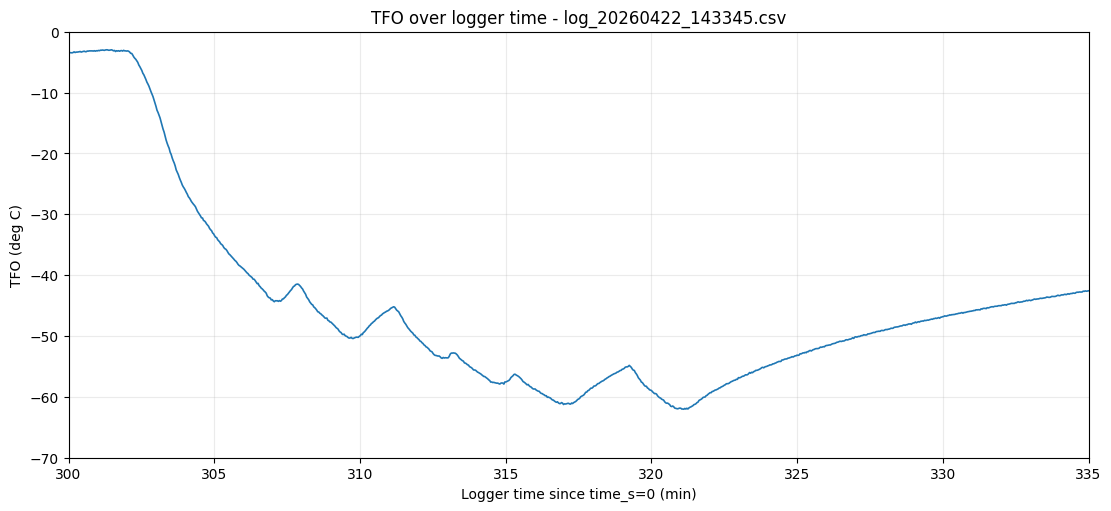

In [2]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

ax.plot(df["elapsed_min"], df[TFO_COLUMN], linewidth=1.2)
ax.set_xlabel("Logger time since time_s=0 (min)")
ax.set_ylabel("TFO (deg C)")
ax.set_ylim(-70, 0)
ax.set_xlim(300, 335)
ax.set_title("TFO over logger time - log_20260422_143345.csv")
ax.grid(True, alpha=0.25)

plt.show()

## Best-fit cooldown and warmup rates

Fit straight lines to `TFO_C` over two logger-time windows: 311.25-312.5 min for cooldown and 325-330 min for warmup. The fitted slope is the rate in deg C/min.

In [3]:
import numpy as np

COOLDOWN_WINDOW_MIN = (311.25, 312.5)
WARMUP_WINDOW_MIN = (325.0, 330.0)


def fit_temperature_window(frame, window_min, y_column=TFO_COLUMN):
    start_min, end_min = window_min
    fit_data = frame.loc[frame["elapsed_min"].between(start_min, end_min)].copy()
    if len(fit_data) < 2:
        raise ValueError(f"Not enough samples in {start_min:g}-{end_min:g} min")

    x = fit_data["elapsed_min"].to_numpy(float)
    y = pd.to_numeric(fit_data[y_column], errors="coerce").to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 2:
        raise ValueError(f"Not enough finite samples in {start_min:g}-{end_min:g} min")

    slope, intercept = np.polyfit(x, y, deg=1)
    fitted = slope * x + intercept
    residual = y - fitted
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

    return fit_data, {
        "window_min": f"{start_min:g}-{end_min:g}",
        "start_min": start_min,
        "end_min": end_min,
        "n_samples": int(len(x)),
        "slope_degC_per_min": float(slope),
        "intercept_degC": float(intercept),
        "r_squared": float(r_squared),
        "temperature_start_fit_degC": float(slope * start_min + intercept),
        "temperature_end_fit_degC": float(slope * end_min + intercept),
    }


cooldown_fit_data, cooldown_fit = fit_temperature_window(df, COOLDOWN_WINDOW_MIN)
warmup_fit_data, warmup_fit = fit_temperature_window(df, WARMUP_WINDOW_MIN)
fit_summary = pd.DataFrame([
    {"phase": "cooldown", **cooldown_fit},
    {"phase": "warmup", **warmup_fit},
])

display(fit_summary[["phase", "window_min", "n_samples", "slope_degC_per_min", "r_squared", "temperature_start_fit_degC", "temperature_end_fit_degC"]])
cooldown_rate_degC_per_min = cooldown_fit["slope_degC_per_min"]
warmup_rate_degC_per_min = warmup_fit["slope_degC_per_min"]
print(f"Cooldown rate: {cooldown_rate_degC_per_min:.3f} deg C/min")
print(f"Warmup rate: {warmup_rate_degC_per_min:.3f} deg C/min")

,phase,window_min,n_samples,slope_degC_per_min,r_squared,temperature_start_fit_degC,temperature_end_fit_degC
0,cooldown,311.25-312.5,36,-5.667892,0.984071,-46.099426,-53.184291
1,warmup,325-330,144,1.247892,0.994904,-52.871016,-46.631555


Cooldown rate: -5.668 deg C/min
Warmup rate: 1.248 deg C/min


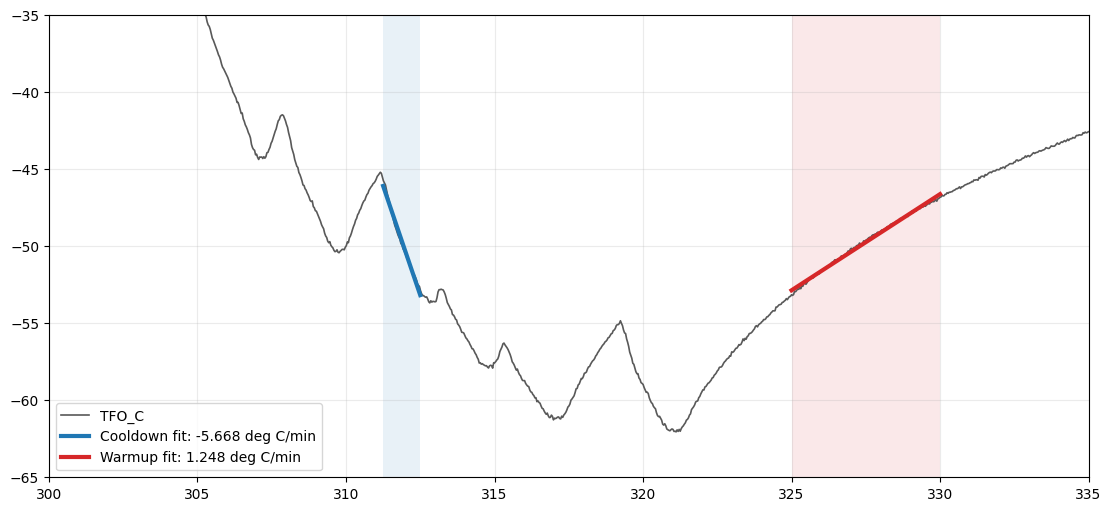

In [4]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

plot_window = df["elapsed_min"].between(300.0, 335.0)
ax.plot(df.loc[plot_window, "elapsed_min"], df.loc[plot_window, TFO_COLUMN], linewidth=1.2, color="0.35", label="TFO_C")

for label, fit, color in [
    ("Cooldown fit", cooldown_fit, "C0"),
    ("Warmup fit", warmup_fit, "C3"),
]:
    x_line = np.linspace(fit["start_min"], fit["end_min"], 100)
    y_line = fit["slope_degC_per_min"] * x_line + fit["intercept_degC"]
    rate = fit["slope_degC_per_min"]
    ax.plot(x_line, y_line, linewidth=3.0, color=color, label=f"{label}: {rate:.3f} deg C/min")
    ax.axvspan(fit["start_min"], fit["end_min"], color=color, alpha=0.10, linewidth=0)


ax.set_xlim(300, 335)
ax.set_ylim(-65, -35)
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.show()

## Cooldown and Warmup data at -100 C

Use `log_20260424_153546.csv` for the cold HFE run. `TFO_C` does not cross `-100 C` in this file, so `THM_C` is used to locate the below-`-100 C` HFE cooldown/warmup cycles, and the straight-line rates are fitted for both `TFO_C` and `THM_C` over those same phase windows.


In [5]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MINUS100_LOG_NAME = "log_20260424_153546.csv"
MINUS100_TFO_COLUMN = "TFO_C"
MINUS100_THRESHOLD_COLUMN = "THM_C"
MINUS100_THRESHOLD_C = -100.0
MINUS100_MIN_COLD_C = -120.0
MINUS100_LOCAL_WARMUP_CENTER_MIN = 170.0
MINUS100_LOCAL_WARMUP_WINDOW_MIN = 5.0
MINUS100_LOCAL_WARMUP_PHASE = "warmup_170min_local"


def find_recirculation_log(log_name, start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for repo_candidate in (start, *start.parents):
        csv_path = repo_candidate / "data" / "raw" / "recirculation" / log_name
        if csv_path.exists():
            return repo_candidate, csv_path
    raise FileNotFoundError(f"Could not find data/raw/recirculation/{log_name} from {start}")


minus100_repo_root, minus100_csv_path = find_recirculation_log(MINUS100_LOG_NAME)

# The first line in this CSV is metadata, so comment="#" skips it.
df_minus100 = pd.read_csv(minus100_csv_path, comment="#")
df_minus100 = df_minus100.sort_values("time_s").reset_index(drop=True)
df_minus100["elapsed_min"] = df_minus100["time_s"] / 60.0

minus100_temperature_ranges = pd.DataFrame(
    [
        {
            "thermocouple": column,
            "min_degC": pd.to_numeric(df_minus100[column], errors="coerce").min(),
            "max_degC": pd.to_numeric(df_minus100[column], errors="coerce").max(),
            "samples_at_or_below_minus100": int(pd.to_numeric(df_minus100[column], errors="coerce").le(MINUS100_THRESHOLD_C).sum()),
        }
        for column in [MINUS100_TFO_COLUMN, MINUS100_THRESHOLD_COLUMN]
    ]
)

display(df_minus100[["elapsed_min", "time_s", MINUS100_TFO_COLUMN, MINUS100_THRESHOLD_COLUMN]].head())
display(minus100_temperature_ranges)
print(f"Loaded {len(df_minus100):,} rows from {minus100_csv_path}")
print(f"Logger time: {df_minus100['elapsed_min'].min():.2f} to {df_minus100['elapsed_min'].max():.2f} min")
print(
    f"{MINUS100_TFO_COLUMN} range: "
    f"{df_minus100[MINUS100_TFO_COLUMN].min():.2f} to {df_minus100[MINUS100_TFO_COLUMN].max():.2f} deg C"
)
print(
    f"{MINUS100_THRESHOLD_COLUMN} range: "
    f"{df_minus100[MINUS100_THRESHOLD_COLUMN].min():.2f} to {df_minus100[MINUS100_THRESHOLD_COLUMN].max():.2f} deg C"
)


,elapsed_min,time_s,TFO_C,THM_C
0,20.341383,1220.483,21.740818,20.322222
1,20.376250,1222.575,21.830673,20.342222
2,20.411117,1224.667,21.830673,20.342222
3,20.445983,1226.759,21.800722,20.332222
4,20.480817,1228.849,21.840657,20.332222


,thermocouple,min_degC,max_degC,samples_at_or_below_minus100
0,TFO_C,-97.866363,21.850641,0
1,THM_C,-142.697778,20.392222,3051


Loaded 9,467 rows from /home/aamy/Documents/hfe-system/data/raw/recirculation/log_20260424_153546.csv
Logger time: 20.34 to 350.38 min
TFO_C range: -97.87 to 21.85 deg C
THM_C range: -142.70 to 20.39 deg C


In [6]:
def fit_temperature_subset(frame, y_column, x_column="elapsed_min"):
    fit_data = frame[[x_column, y_column]].copy()
    fit_data[x_column] = pd.to_numeric(fit_data[x_column], errors="coerce")
    fit_data[y_column] = pd.to_numeric(fit_data[y_column], errors="coerce")
    fit_data = fit_data.dropna()
    if len(fit_data) < 2:
        return None

    x = fit_data[x_column].to_numpy(float)
    y = fit_data[y_column].to_numpy(float)
    slope, intercept = np.polyfit(x, y, deg=1)
    fitted = slope * x + intercept
    residual = y - fitted
    ss_res = float(np.sum(residual**2))
    ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
    r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0.0 else np.nan

    return {
        "n_samples": int(len(fit_data)),
        "start_min": float(x.min()),
        "end_min": float(x.max()),
        "duration_min": float(x.max() - x.min()),
        "slope_degC_per_min": float(slope),
        "intercept_degC": float(intercept),
        "r_squared": float(r_squared),
        "temperature_start_fit_degC": float(slope * x.min() + intercept),
        "temperature_end_fit_degC": float(slope * x.max() + intercept),
        "temperature_start_sample_degC": float(y[0]),
        "temperature_end_sample_degC": float(y[-1]),
    }


minus100_work = df_minus100.copy()
minus100_work[MINUS100_THRESHOLD_COLUMN] = pd.to_numeric(minus100_work[MINUS100_THRESHOLD_COLUMN], errors="coerce")
minus100_below_mask = minus100_work[MINUS100_THRESHOLD_COLUMN].le(MINUS100_THRESHOLD_C)
minus100_work["minus100_segment"] = minus100_below_mask.ne(minus100_below_mask.shift(fill_value=False)).cumsum()

minus100_fit_rows = []
minus100_phase_frames = []
minus100_cycle_number = 1

for segment_id, below_segment in minus100_work.loc[minus100_below_mask].groupby("minus100_segment", sort=True):
    below_segment = below_segment.sort_values("elapsed_min").copy()
    if len(below_segment) < 4:
        continue
    cold_min_C = float(below_segment[MINUS100_THRESHOLD_COLUMN].min())
    if cold_min_C > MINUS100_MIN_COLD_C:
        continue

    coldest_position = int(np.nanargmin(below_segment[MINUS100_THRESHOLD_COLUMN].to_numpy(float)))
    phase_slices = [
        ("cooldown", below_segment.iloc[: coldest_position + 1].copy()),
        ("warmup", below_segment.iloc[coldest_position:].copy()),
    ]

    for phase_name, phase_frame in phase_slices:
        if len(phase_frame) < 2:
            continue
        phase_frame["minus100_cycle_number"] = minus100_cycle_number
        phase_frame["cycle_phase"] = phase_name
        phase_frame["time_since_phase_start_min"] = phase_frame["elapsed_min"] - float(phase_frame["elapsed_min"].iloc[0])
        phase_frame["cold_min_THM_C"] = cold_min_C
        minus100_phase_frames.append(phase_frame)

        for thermocouple in [MINUS100_TFO_COLUMN, MINUS100_THRESHOLD_COLUMN]:
            fit = fit_temperature_subset(phase_frame, thermocouple)
            if fit is None:
                continue
            minus100_fit_rows.append(
                {
                    "minus100_cycle_number": minus100_cycle_number,
                    "below100_segment": int(segment_id),
                    "phase": phase_name,
                    "thermocouple": thermocouple,
                    "cold_min_THM_C": cold_min_C,
                    **fit,
                }
            )

    minus100_cycle_number += 1

minus100_phase_samples = pd.concat(minus100_phase_frames, ignore_index=True) if minus100_phase_frames else pd.DataFrame()
minus100_fit_summary = pd.DataFrame(minus100_fit_rows)

minus100_local_warmup_start_min = MINUS100_LOCAL_WARMUP_CENTER_MIN - MINUS100_LOCAL_WARMUP_WINDOW_MIN / 2.0
minus100_local_warmup_end_min = MINUS100_LOCAL_WARMUP_CENTER_MIN + MINUS100_LOCAL_WARMUP_WINDOW_MIN / 2.0
minus100_local_warmup_samples = df_minus100.loc[
    df_minus100["elapsed_min"].between(minus100_local_warmup_start_min, minus100_local_warmup_end_min)
].copy()

minus100_local_fit_rows = []
if not minus100_local_warmup_samples.empty:
    reference_cycle_number = (
        int(minus100_fit_summary["minus100_cycle_number"].max())
        if not minus100_fit_summary.empty
        else pd.NA
    )
    reference_cycle_rows = minus100_fit_summary.loc[
        minus100_fit_summary["minus100_cycle_number"].eq(reference_cycle_number)
    ]
    reference_below100_segment = (
        int(reference_cycle_rows["below100_segment"].dropna().iloc[0])
        if not reference_cycle_rows.empty and not reference_cycle_rows["below100_segment"].dropna().empty
        else pd.NA
    )
    reference_cold_min_C = (
        float(reference_cycle_rows["cold_min_THM_C"].dropna().iloc[0])
        if not reference_cycle_rows.empty and not reference_cycle_rows["cold_min_THM_C"].dropna().empty
        else np.nan
    )

    for thermocouple in [MINUS100_TFO_COLUMN, MINUS100_THRESHOLD_COLUMN]:
        fit = fit_temperature_subset(minus100_local_warmup_samples, thermocouple)
        if fit is None:
            continue
        minus100_local_fit_rows.append(
            {
                "minus100_cycle_number": reference_cycle_number,
                "below100_segment": reference_below100_segment,
                "phase": MINUS100_LOCAL_WARMUP_PHASE,
                "thermocouple": thermocouple,
                "cold_min_THM_C": reference_cold_min_C,
                "window_center_min": MINUS100_LOCAL_WARMUP_CENTER_MIN,
                "window_width_min": MINUS100_LOCAL_WARMUP_WINDOW_MIN,
                **fit,
            }
        )

minus100_local_fit_summary = pd.DataFrame(minus100_local_fit_rows)
if not minus100_local_fit_summary.empty:
    minus100_fit_summary = pd.concat([minus100_fit_summary, minus100_local_fit_summary], ignore_index=True)

minus100_phase_rate_summary = (
    minus100_fit_summary
    .groupby(["thermocouple", "phase"], as_index=False)
    .agg(
        cycles=("minus100_cycle_number", "count"),
        mean_rate_degC_per_min=("slope_degC_per_min", "mean"),
        median_rate_degC_per_min=("slope_degC_per_min", "median"),
        std_rate_degC_per_min=("slope_degC_per_min", "std"),
        min_rate_degC_per_min=("slope_degC_per_min", "min"),
        max_rate_degC_per_min=("slope_degC_per_min", "max"),
        mean_r_squared=("r_squared", "mean"),
    )
)

minus100_processed_dir = minus100_repo_root / "data" / "processed" / "recirculation_trendline"
minus100_processed_dir.mkdir(parents=True, exist_ok=True)
minus100_fit_summary_path = minus100_processed_dir / "apr24_minus100_cooldown_warmup_fit_summary.csv"
minus100_phase_samples_path = minus100_processed_dir / "apr24_minus100_cooldown_warmup_phase_samples.csv"
minus100_fit_summary.to_csv(minus100_fit_summary_path, index=False)
minus100_phase_samples.to_csv(minus100_phase_samples_path, index=False)

display(
    minus100_fit_summary[
        [
            "minus100_cycle_number",
            "phase",
            "thermocouple",
            "start_min",
            "end_min",
            "duration_min",
            "n_samples",
            "slope_degC_per_min",
            "r_squared",
            "temperature_start_sample_degC",
            "temperature_end_sample_degC",
            "cold_min_THM_C",
        ]
    ]
)
display(minus100_phase_rate_summary)
minus100_below_cycle_count = minus100_fit_summary.loc[
    minus100_fit_summary["phase"].ne(MINUS100_LOCAL_WARMUP_PHASE), "minus100_cycle_number"
].nunique()
print(f"Retained {minus100_below_cycle_count} below -100 C cycles with THM minima <= {MINUS100_MIN_COLD_C:g} C")
print(
    f"Added local warmup fit centered at {MINUS100_LOCAL_WARMUP_CENTER_MIN:g} min "
    f"over a {MINUS100_LOCAL_WARMUP_WINDOW_MIN:g} min window"
)
print(f"Saved fit summary to {minus100_fit_summary_path}")
print(f"Saved phase samples to {minus100_phase_samples_path}")


,minus100_cycle_number,phase,thermocouple,start_min,end_min,duration_min,n_samples,slope_degC_per_min,r_squared,temperature_start_sample_degC,temperature_end_sample_degC,cold_min_THM_C
0,1,cooldown,TFO_C,56.459883,57.226867,0.766983,23,0.511935,0.252060,-63.801279,-63.262149,-122.347778
1,1,cooldown,THM_C,56.459883,57.226867,0.766983,23,-28.546487,0.938051,-100.367778,-122.347778,-122.347778
2,1,warmup,TFO_C,57.226867,58.516950,1.290083,38,-3.724335,0.873354,-63.262149,-67.265694,-122.347778
3,1,warmup,THM_C,57.226867,58.516950,1.290083,38,15.444793,0.909537,-122.347778,-101.057778,-122.347778
4,2,cooldown,TFO_C,60.225117,61.375717,1.150600,34,-1.454944,0.922149,-66.796451,-68.673425,-122.997778
...,...,...,...,...,...,...,...,...,...,...,...,...
77,20,cooldown,THM_C,127.941317,135.473017,7.531700,217,-1.709110,0.259479,-101.247778,-135.757778,-135.757778
78,20,warmup,TFO_C,135.473017,167.971367,32.498350,933,-0.140597,0.895510,-93.952672,-97.017731,-135.757778
79,20,warmup,THM_C,135.473017,167.971367,32.498350,933,0.728738,0.485288,-135.757778,-100.067778,-135.757778
80,20,warmup_170min_local,TFO_C,167.517933,172.469367,4.951433,143,1.602351,0.976873,-96.947844,-90.118853,-135.757778


,thermocouple,phase,cycles,mean_rate_degC_per_min,median_rate_degC_per_min,std_rate_degC_per_min,min_rate_degC_per_min,max_rate_degC_per_min,mean_r_squared
0,TFO_C,cooldown,20,-0.480003,-0.390905,0.583844,-1.638453,0.511935,0.517238
1,TFO_C,warmup,20,-0.930518,-0.706603,0.768187,-3.724335,-0.140597,0.844258
2,TFO_C,warmup_170min_local,1,1.602351,1.602351,NaN,1.602351,1.602351,0.976873
3,THM_C,cooldown,20,-24.056945,-27.564873,10.139687,-32.464044,-1.298981,0.736928
4,THM_C,warmup,20,13.385710,12.799233,5.860715,0.728738,32.886214,0.803088
5,THM_C,warmup_170min_local,1,2.396079,2.396079,NaN,2.396079,2.396079,0.980038


Retained 20 below -100 C cycles with THM minima <= -120 C
Added local warmup fit centered at 170 min over a 5 min window
Saved fit summary to /home/aamy/Documents/hfe-system/data/processed/recirculation_trendline/apr24_minus100_cooldown_warmup_fit_summary.csv
Saved phase samples to /home/aamy/Documents/hfe-system/data/processed/recirculation_trendline/apr24_minus100_cooldown_warmup_phase_samples.csv


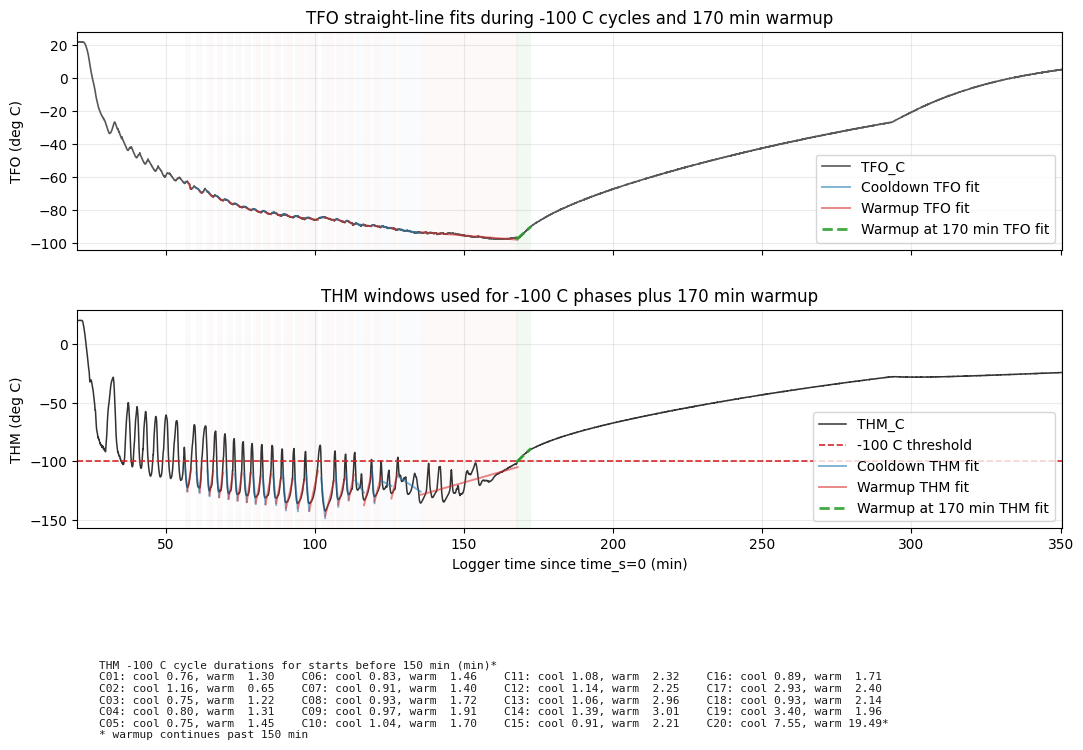

In [7]:
minus100_tfo_fits = minus100_fit_summary.loc[minus100_fit_summary["thermocouple"].eq(MINUS100_TFO_COLUMN)].copy()
minus100_thm_fits = minus100_fit_summary.loc[minus100_fit_summary["thermocouple"].eq(MINUS100_THRESHOLD_COLUMN)].copy()

plot_start_min = df_minus100["elapsed_min"].min()
plot_end_min = df_minus100["elapsed_min"].max()
plot_window = df_minus100["elapsed_min"].between(plot_start_min, plot_end_min)
fit_colors = {"cooldown": "C0", "warmup": "C3", MINUS100_LOCAL_WARMUP_PHASE: "C2"}
fit_phase_labels = {
    "cooldown": "Cooldown",
    "warmup": "Warmup",
    MINUS100_LOCAL_WARMUP_PHASE: "Warmup at 170 min",
}

MINUS100_DURATION_CUTOFF_MIN = 150.0
MINUS100_DURATION_TABLE_COLUMNS = 4
MINUS100_DURATION_SUMMARY_PATH = (
    minus100_repo_root
    / "data"
    / "processed"
    / "HFE_measurements"
    / "apr24_minus100_cooldown_warmup_summary.csv"
)


def minus100_duration_table_text(summary_path=MINUS100_DURATION_SUMMARY_PATH):
    if not summary_path.exists():
        return ""

    summary = pd.read_csv(summary_path)
    required_columns = [
        "minus100_cycle_number",
        "start_elapsed_min",
        "end_elapsed_min",
        "cooldown_duration_min",
        "warmup_duration_min",
    ]
    missing_columns = [column for column in required_columns if column not in summary.columns]
    if missing_columns:
        raise RuntimeError(f"Missing duration summary columns: {missing_columns}")

    rows = summary.loc[
        summary["start_elapsed_min"].le(MINUS100_DURATION_CUTOFF_MIN + 1e-12),
        required_columns,
    ].copy()
    if rows.empty:
        return ""

    rows = rows.sort_values("minus100_cycle_number").reset_index(drop=True)
    has_late_warmup = bool(rows["end_elapsed_min"].gt(MINUS100_DURATION_CUTOFF_MIN + 1e-12).any())
    header_suffix = "*" if has_late_warmup else ""
    lines = [
        f"THM -100 C cycle durations for starts before {MINUS100_DURATION_CUTOFF_MIN:.0f} min (min){header_suffix}"
    ]
    entries = []
    for _, row in rows.iterrows():
        late_suffix = "*" if row["end_elapsed_min"] > MINUS100_DURATION_CUTOFF_MIN + 1e-12 else " "
        entries.append(
            f"C{int(row['minus100_cycle_number']):02d}: cool {row['cooldown_duration_min']:4.2f}, "
            f"warm {row['warmup_duration_min']:5.2f}{late_suffix}"
        )

    rows_per_column = int(np.ceil(len(entries) / MINUS100_DURATION_TABLE_COLUMNS))
    for offset in range(rows_per_column):
        lines.append("   ".join(entries[offset::rows_per_column]))
    if has_late_warmup:
        lines.append(f"* warmup continues past {MINUS100_DURATION_CUTOFF_MIN:.0f} min")
    return "\n".join(lines)


fig, (ax_tfo, ax_thm) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, constrained_layout=False)

ax_tfo.plot(
    df_minus100.loc[plot_window, "elapsed_min"],
    df_minus100.loc[plot_window, MINUS100_TFO_COLUMN],
    linewidth=1.2,
    color="0.35",
    label=MINUS100_TFO_COLUMN,
)

seen_tfo_labels = set()
for _, fit in minus100_tfo_fits.iterrows():
    phase = fit["phase"]
    color = fit_colors.get(phase, "C7")
    phase_label = fit_phase_labels.get(phase, phase.replace("_", " " ).title())
    is_local_170min_fit = phase == MINUS100_LOCAL_WARMUP_PHASE
    x_line = np.linspace(fit["start_min"], fit["end_min"], 50)
    y_line = fit["slope_degC_per_min"] * x_line + fit["intercept_degC"]
    label = f"{phase_label} TFO fit" if phase not in seen_tfo_labels else None
    ax_tfo.plot(
        x_line,
        y_line,
        linewidth=2.0 if is_local_170min_fit else 1.4,
        color=color,
        alpha=0.9 if is_local_170min_fit else 0.55,
        linestyle="--" if is_local_170min_fit else "-",
        label=label,
    )
    ax_tfo.axvspan(
        fit["start_min"],
        fit["end_min"],
        color=color,
        alpha=0.06 if is_local_170min_fit else 0.025,
        linewidth=0,
    )
    seen_tfo_labels.add(phase)

ax_thm.plot(
    df_minus100.loc[plot_window, "elapsed_min"],
    df_minus100.loc[plot_window, MINUS100_THRESHOLD_COLUMN],
    linewidth=1.1,
    color="0.20",
    label=MINUS100_THRESHOLD_COLUMN,
)
ax_thm.axhline(MINUS100_THRESHOLD_C, color="tab:red", linestyle="--", linewidth=1.2, label="-100 C threshold")

seen_thm_labels = set()
for _, fit in minus100_thm_fits.iterrows():
    phase = fit["phase"]
    color = fit_colors.get(phase, "C7")
    phase_label = fit_phase_labels.get(phase, phase.replace("_", " " ).title())
    is_local_170min_fit = phase == MINUS100_LOCAL_WARMUP_PHASE
    x_line = np.linspace(fit["start_min"], fit["end_min"], 50)
    y_line = fit["slope_degC_per_min"] * x_line + fit["intercept_degC"]
    label = f"{phase_label} THM fit" if phase not in seen_thm_labels else None
    ax_thm.plot(
        x_line,
        y_line,
        linewidth=2.0 if is_local_170min_fit else 1.4,
        color=color,
        alpha=0.9 if is_local_170min_fit else 0.55,
        linestyle="--" if is_local_170min_fit else "-",
        label=label,
    )
    ax_thm.axvspan(
        fit["start_min"],
        fit["end_min"],
        color=color,
        alpha=0.06 if is_local_170min_fit else 0.025,
        linewidth=0,
    )
    seen_thm_labels.add(phase)

ax_tfo.set_ylabel("TFO (deg C)")
ax_tfo.set_title("TFO straight-line fits during -100 C cycles and 170 min warmup")
ax_tfo.grid(True, alpha=0.25)
ax_tfo.legend(loc="best")

ax_thm.set_xlabel("Logger time since time_s=0 (min)")
ax_thm.set_ylabel("THM (deg C)")
ax_thm.set_title("THM windows used for -100 C phases plus 170 min warmup")
ax_thm.set_xlim(plot_start_min, plot_end_min)
ax_thm.grid(True, alpha=0.25)
ax_thm.legend(loc="best")

minus100_duration_text = minus100_duration_table_text()
if minus100_duration_text:
    fig.text(
        0.11,
        0.035,
        minus100_duration_text,
        ha="left",
        va="bottom",
        fontsize=8.0,
        family="monospace",
        color="0.10",
    )
fig.subplots_adjust(left=0.09, right=0.985, top=0.92, bottom=0.30, hspace=0.28)

plt.show()
